## Tutorial 1: การติดตั้งและใช้งาน marimo บน Google Colab




marimo-logotype-thick.svg

 marimo คือ reactive Python notebook ที่เมื่อเราสร้าง UI element (เช่น button, dropdown หรือ slide bar) แล้วป้อน input เข้าไป marimo จะรัน cell อื่นที่เกี่ยวข้องโดยอัตโนมัต ซึ่งจะทำให้ค่า output ที่ได้มาจาก UI ไปแสดงผลบน cell อื่นๆ โดยที่เราไม่ต้องกลับไปรันซ้ำ

 https://docs.marimo.io/

ติดตั้ง marimo

รันคำสั่งนี้ใน cell แรกของ Google Colab:

In [ ]:
!pip install marimo

หลังจากติดตั้งเสร็จ ให้รัน cell นี้เพื่อเปิด marimo tutorial

In [ ]:
import subprocess
subprocess.Popen(
      ["marimo", "tutorial", "intro", "--host", "0.0.0.0", "-p", "7860", "--headless",
       "--no-token"]
  )
from google.colab.output import eval_js
print("Open the app here:", eval_js('google.colab.kernel.proxyPort(7860)'))

เพิ่มเติม:
* [ใช้งาน marimo บนเครื่องตัวเอง](https://docs.marimo.io/getting_started/installation/)
* [ใช้งาน marimo บน molab](https://molab.marimo.io/notebooks)

### ทำไมถึงรัน marimo บน Google Colab?

การรัน **marimo บน Google Colab** มีข้อดีคือ เราสามารถใช้ resource ของ Colab ได้ ดังนั้น marimo ที่เราเปิดผ่าน Colab จะไม่ได้ใช้ทรัพยากรจากเครื่องเราโดยตรง แต่ใช้เครื่องของ Colab เป็นหลัก

#### เปรียบเทียบการรัน marimo

| วิธี | Resource |
|---|---|
| **Colab GPU runtime** | CPU / 12 GB RAM ของ Colab + GPU เช่น T4 ตาม availability |
| **Local** | CPU/RAM/GPU ของเครื่องตัวเอง |
| **molab free tier** | 2 CPU / 2 GB RAM, ไม่มี GPU |


เมื่อเทียบกับการรันบนเครื่องเรา ถ้า RAM น้อย หรือไม่มี GPU การรัน model ใหญ่ๆ อาจช้า หรือรันไม่ไหวเช่นเดียวกับการใช้ molab ที่ไม่มี GPU

### ตัวอย่างโปรเจคที่ใช้ marimo


[Showcase Notebooks ที่สร้างด้วย marimo](https://marimo.io/gallery)

[Notebook Visualizing Embeddings](https://molab.marimo.io/github/marimo-team/gallery-examples/blob/main/notebooks/algorithms/visualizing-embeddings.py)

ไฟล์ตัวอย่าง

[visualizing-embeddings.py](https://github.com/marimo-team/gallery-examples/blob/main/notebooks/algorithms/visualizing-embeddings.py)

In [ ]:
!wget -O visualizing_embeddings.py https://raw.githubusercontent.com/marimo-team/gallery-examples/main/notebooks/algorithms/visualizing-embeddings.py

ในกรณีที่ เริ่ม notebook ใหม่หรือ restart session
*แนะนำให้รันด้วย CPU

In [ ]:
import subprocess
subprocess.Popen(
      ["marimo", "edit", "visualizing_embeddings.py", "--host", "0.0.0.0", "-p", "7860", "--headless",
       "--no-token"]
  )
from google.colab.output import eval_js
print("Open the app here:", eval_js('google.colab.kernel.proxyPort(7860)'))

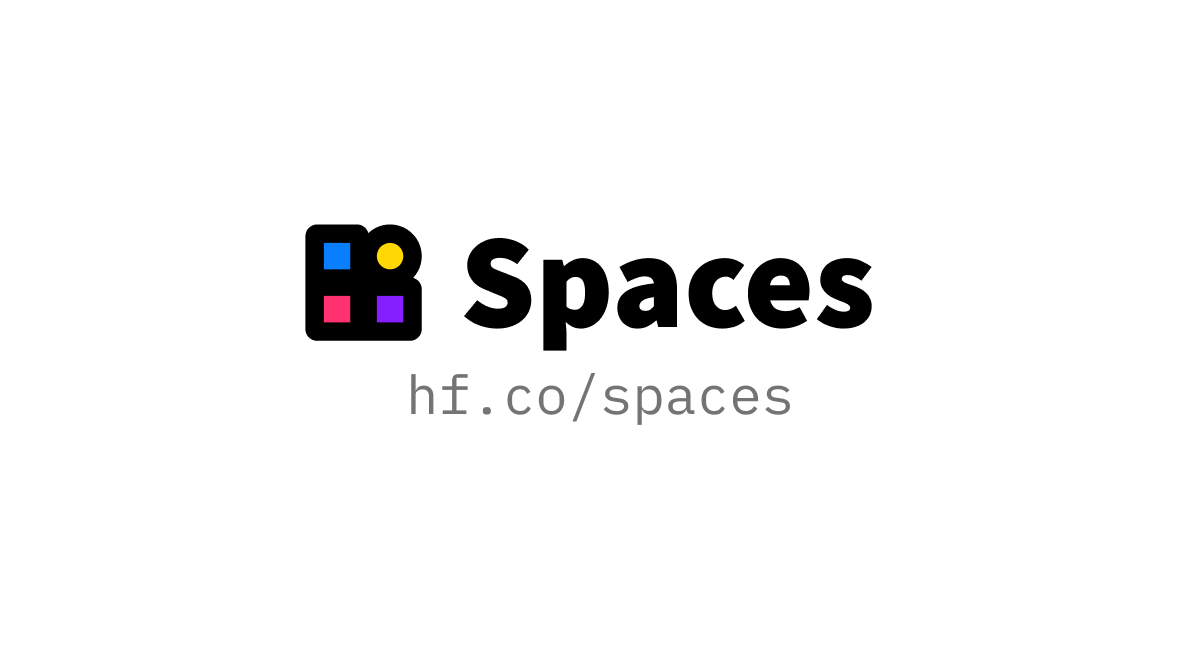

## Tutorial 2: การ Deploy Application ของเราบน Hugging Face Space

https://huggingface.co/new-space

## Extra: Satellite VQA + Marimo

### เทคนิค: การเช็ค GPU บน Colab

รันสคริปนี้ข้างใน marimo

```python
import marimo as mo
import torch
import subprocess

cuda_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if cuda_available else "No CUDA GPU"

nvidia_smi = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True,
).stdout

mo.md(f"""
## GPU check

**CUDA available:** `{cuda_available}`  
**GPU:** `{gpu_name}`

{nvidia_smi}

""")
```

### เทคนิค: การ Download model file บน Hugging Face Hub เข้ามาไว้ใน Colab

In [ ]:
from huggingface_hub import login
from google.colab import userdata
login(userdata.get('HF_TOKEN'))

from huggingface_hub import snapshot_download
MODEL_ID = "monradach/qwen3-vl-satellite-vqa"
MODEL_DIR = "/content/hf_models/qwen3-vl-satellite-vqa"
snapshot_download(MODEL_ID, local_dir=MODEL_DIR, token=True)

### การติดตั้งและรัน Satellite VQA + Marimo Application บน Colab ด้วย GPU

ติดตั้ง uv เพื่อความรวดเร็วในการติดตั้ง package อื่นๆ

ดูเพิ่มเติมได้ที่ https://docs.astral.sh/uv/

In [ ]:
!pip install uv

สร้างไฟล์ requirements.txt
 สำหรับ Satellite VQA + Marimo Application บน *Colab*

In [ ]:
%%writefile requirements.txt
marimo==0.23.8
ipywidgets==8.1.8
anywidget==0.11.0
accelerate
huggingface-hub>=1.16.4
numpy>=1.26
pillow>=12.2.0
pystac-client>=0.8
rasterio
rioxarray>=0.15
torch>=2.4
torchvision>=0.19
transformers>=4.57

ติดตั้ง package ที่จำเป็น

In [ ]:
!uv pip install --system -r requirements.txt

สร้างไฟล์ app.py สำหรับ Satellite VQA + Marimo Application บน *Colab*

In [ ]:
%%writefile app.py
"""
Satellite VQA — แอป marimo สำหรับการสอน

คลิกบริเวณใดบนแผนที่ก็ได้ -> แอปจะดึงภาพถ่าย Sentinel-2 ของจุดนั้น
จาก AWS Earth Search (ฟรี ไม่ต้องสมัครบัญชี) แล้วถามโมเดล fine-tuned โดยอัตโนมัติ
ค่าเริ่มต้นชี้ที่กรุงเทพฯ

รันบน CPU ได้ โมเดลจะถูกโหลดตอนเริ่ม inference จะช้าถ้าไม่มี GPU
"""

# โหลด IPython/tqdm ก่อนใน main thread ก่อนที่ marimo จะติดตั้ง formatter hook
# ไม่อย่างงั้นบน Python 3.12 import chain torch -> tqdm -> tqdm.notebook ->
# ipywidgets -> IPython จะเกิด race condition กับ formatter ของ marimo จนเกิด deadlock ตอนเริ่ม session (เช่นบน HF Spaces GPU)
import IPython.display  # noqa: F401, E402
import tqdm.notebook  # noqa: F401, E402

import marimo

__generated_with = "0.23.8"
app = marimo.App(width="full", auto_download=["html"])


@app.cell
def _():
    import os
    import datetime as dt

    import marimo as mo
    import numpy as np
    import pystac_client
    import rioxarray  # noqa: F401
    from rasterio.warp import transform_bounds
    from PIL import Image

    import torch

    # ชื่อโมเดลที่ใช้งานบน Hugging Face Hub
    MODEL_ID = "monradach/qwen3-vl-satellite-vqa"
    MODEL_PATH = os.environ.get("MODEL_PATH", MODEL_ID)

    from transformers import AutoModelForImageTextToText, AutoProcessor

    processor = AutoProcessor.from_pretrained(
        MODEL_PATH, trust_remote_code=True,
    )
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_PATH,
        torch_dtype="auto",
        device_map="auto",
        trust_remote_code=True
    )
    return (
        Image,
        dt,
        mo,
        model,
        np,
        processor,
        pystac_client,
        rioxarray,
        torch,
        transform_bounds,
    )


@app.cell
def _(mo):
    # หัวข้อและคำอธิบายการใช้งานสั้น ๆ ที่ด้านบนของแอป
    mo.md("""
    ## 🛰️ ตัวบรรยายภาพถ่ายดาวเทียม
    คลิกบริเวณใดก็ได้บนแผนที่เพื่อโหลดภาพ Sentinel-2 ของจุดนั้น
    จากนั้นกด **Analyze ▶** เพื่อให้โมเดลบรรยายฉาก
    """)
    return


@app.cell
def _(mo):
    # widget แผนที่ที่คลิกได้ ใช้ OpenLayers ฝังผ่าน anywidget
    # คลิกบนแผนที่จะส่งพิกัด [lat, lon] กลับมาให้ฝั่ง Python
    import anywidget
    import traitlets

    class ClickMap(anywidget.AnyWidget):
        _esm = """
        import Map from "https://esm.sh/ol@10/Map.js";
        import View from "https://esm.sh/ol@10/View.js";
        import TileLayer from "https://esm.sh/ol@10/layer/Tile.js";
        import OSM from "https://esm.sh/ol@10/source/OSM.js";
        import VectorLayer from "https://esm.sh/ol@10/layer/Vector.js";
        import VectorSource from "https://esm.sh/ol@10/source/Vector.js";
        import Feature from "https://esm.sh/ol@10/Feature.js";
        import { fromExtent } from "https://esm.sh/ol@10/geom/Polygon.js";
        import { Style, Stroke, Fill } from "https://esm.sh/ol@10/style.js";
        import { fromLonLat, toLonLat } from "https://esm.sh/ol@10/proj.js";

        const HALF_M = 224 * 10 / 2;   // 1120 m -> เท่ากับสี่เหลี่ยม 2.24 km ของ chip ที่ดึงมา

        function render({ model, el }) {
          const div = document.createElement("div");
          div.style.height = "440px";
          div.style.width = "100%";
          el.appendChild(div);

          const boxSource = new VectorSource();
          const boxLayer = new VectorLayer({
            source: boxSource,
            style: new Style({
              stroke: new Stroke({ color: "red", width: 2 }),
              fill: new Fill({ color: "rgba(255,0,0,0.08)" }),
            }),
          });

          const [lat0, lon0] = model.get("clicked");
          const map = new Map({
            target: div,
            layers: [new TileLayer({ source: new OSM() }), boxLayer],
            view: new View({ center: fromLonLat([lon0, lat0]), zoom: model.get("zoom") }),
          });

          function extentOf(lon, lat) {
            const dlat = HALF_M / 111320;
            const dlon = HALF_M / (111320 * Math.cos(lat * Math.PI / 180));
            const mn = fromLonLat([lon - dlon, lat - dlat]);
            const mx = fromLonLat([lon + dlon, lat + dlat]);
            return [mn[0], mn[1], mx[0], mx[1]];
          }

          function drawBox(lon, lat) {
            boxSource.clear();
            boxSource.addFeature(new Feature(fromExtent(extentOf(lon, lat))));
          }

          map.on("click", (e) => {
            const [clon, clat] = toLonLat(e.coordinate);
            drawBox(clon, clat);                     // วาดกรอบบริเวณที่จะดึงภาพ (ไม่ zoom)
            model.set("clicked", [clat, clon]);      // เก็บเป็น [lat, lon] -> ส่งกลับ Python
            model.save_changes();
          });

          setTimeout(() => { map.updateSize(); drawBox(lon0, lat0); }, 300);
        }
        export default { render };
        """
        _css = "@import url('https://esm.sh/ol@10/ol.css');"
        zoom = traitlets.Int(14).tag(sync=True)
        # พิกัดเริ่มต้น [lat, lon] ของกรุงเทพฯ
        clicked = traitlets.List([13.7563, 100.5018]).tag(sync=True)

    map_widget = mo.ui.anywidget(ClickMap())
    map_widget
    return (map_widget,)


@app.cell
def _(Image, dt, np, pystac_client, rioxarray, transform_bounds):
    def fetch_s2(bbox, max_cloud=10, size=224):   # 224 px = ขนาด chip ที่ใช้เทรนโมเดล
        """ดึงภาพ Sentinel-2 สี true-color จาก bbox (lon/lat) คืนเป็น PIL Image
        เลือก scene ล่าสุดที่เมฆน้อยที่สุด"""
        # เปิด catalog ของ Earth Search (STAC)
        catalog = pystac_client.Client.open(
            "https://earth-search.aws.element84.com/v1"
        )
        # ค้นย้อนหลัง 180 วัน เรียงจาก cloud cover น้อยไปมาก
        end = dt.date.today()
        start = end - dt.timedelta(days=180)
        search = catalog.search(
            collections=["sentinel-2-l2a"],
            bbox=bbox,
            datetime=f"{start}/{end}",
            query={"eo:cloud_cover": {"lt": max_cloud}},
            sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
            max_items=12,
        )
        items = list(search.items())
        if not items:
            raise RuntimeError("ไม่พบภาพ Sentinel-2 ที่ฟ้าเปิดในพื้นที่/ช่วงเวลานี้")

        # เลือก granule (ที่เมฆน้อย) ซึ่งครอบคลุมพื้นที่ทั้งหมด เพราะ S2 tile เดียว
        # อาจตัดขอบ bbox ออกได้ ถ้าไม่มีตัวที่ครอบคลุม fallback ไปใช้ตัวที่ overlap มากที่สุด
        def covers(it):
            ib = it.bbox
            return ib[0] <= bbox[0] and ib[1] <= bbox[1] and ib[2] >= bbox[2] and ib[3] >= bbox[3]

        def overlap(it):
            ib = it.bbox
            ox = max(0, min(ib[2], bbox[2]) - max(ib[0], bbox[0]))
            oy = max(0, min(ib[3], bbox[3]) - max(ib[1], bbox[1]))
            return ox * oy

        item = next((it for it in items if covers(it)), max(items, key=overlap))

        # asset "visual" = COG แบบ RGB 8-bit true-color ที่ render ไว้แล้ว อ่านเฉพาะ window ของ bbox
        href = item.assets["visual"].href
        da = rioxarray.open_rasterio(href)                 # dims: (band, y, x), uint8 3 ช่อง
        # COG อยู่ใน UTM ต้องแปลง bbox lon/lat ให้เป็น CRS เดียวกับ raster ก่อน clip
        left, bottom, right, top = transform_bounds("EPSG:4326", da.rio.crs, *bbox)
        da = da.rio.clip_box(left, bottom, right, top)
        rgb = da.transpose("y", "x", "band").values
        img = Image.fromarray(np.asarray(rgb, dtype=np.uint8))
        return img.resize((size, size))

    return (fetch_s2,)


@app.cell
def _(model, processor, torch):
    def answer(image: "Image.Image", question: str) -> str:
        """ส่งภาพ + คำถาม 1 รอบเข้าโมเดล แล้วคืนข้อความที่ generate ออกมา (greedy)"""
        # สร้าง chat message แบบ multimodal: รูป + ข้อความ
        messages = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}]
        inputs = processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=True,
            return_dict=True, return_tensors="pt",
        ).to(model.device)
        # generate แบบไม่ sample (greedy) เพื่อให้ผลลัพธ์เสถียร
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
        # ตัด token ของ prompt ออก เหลือเฉพาะส่วนที่โมเดลตอบ
        gen = out[0][inputs["input_ids"].shape[1]:]
        return processor.decode(gen, skip_special_tokens=True).strip()

    return (answer,)


@app.cell
def _():
    # prompt มาตรฐานสำหรับให้โมเดลบรรยายภาพดาวเทียม
    prompt = ("The input is satellite imagery (RGB). Describe this imagery in "
              "detail, including surface cover and structure where visible.")
    return (prompt,)


@app.cell
def _(fetch_s2, map_widget, mo):
    # ดึงพิกัดที่ผู้ใช้คลิก แล้วคำนวณ bbox 2.24 km รอบจุดนั้น และดึงภาพ
    import io as _io
    import math as _math

    _lat, _lon = map_widget.value["clicked"]     # [lat, lon] จากการคลิกบนแผนที่
    # 224 px ที่ 10 m/px = สี่เหลี่ยม 2.24 km (ตรงกับขนาด chip ตอนเทรน)
    _half_m = 224 * 10 / 2
    _dlat = _half_m / 111_320
    _dlon = _half_m / (111_320 * _math.cos(_math.radians(_lat)))
    _bbox = [_lon - _dlon, _lat - _dlat, _lon + _dlon, _lat + _dlat]

    chip = None
    try:
        chip = fetch_s2(_bbox)
        _buf = _io.BytesIO()
        chip.save(_buf, format="PNG")
        _img = mo.image(_buf.getvalue(), width=320)
    except Exception as _e:                      # กรณีเมฆเยอะ / พื้นที่ว่าง / ไม่พบ scene
        _img = mo.callout(mo.md(f"ดึงภาพไม่สำเร็จ: `{_e}`"), kind="danger")

    mo.vstack([
        mo.md(f"**ตำแหน่ง:** {_lat:.4f}, {_lon:.4f} — Sentinel-2 (224 px ≈ 2.2 km)"),
        _img,
    ])
    return (chip,)


@app.cell
def _(mo):
    # ปุ่มสำหรับสั่งให้โมเดลเริ่มวิเคราะห์ภาพ
    analyze = mo.ui.run_button(label="Analyze ▶", kind="success", full_width=True)
    analyze
    return (analyze,)


@app.cell
def _(analyze, answer, chip, mo, prompt):
    # ถ้ายังไม่ได้กดปุ่ม ให้แสดงข้อความรอ แล้วหยุด cell นี้
    mo.stop(not analyze.value, mo.md("_กด **Analyze ▶** เพื่อให้โมเดลบรรยายฉากนี้_"))

    if chip is None:
        _out = mo.callout(mo.md("ไม่มีภาพให้วิเคราะห์"), kind="warn")
    else:
        try:
            # แสดง spinner ระหว่างที่โมเดลกำลังประมวลผล
            with mo.status.spinner(title="กำลังวิเคราะห์ภาพ…",
                                   subtitle="โมเดลกำลังประมวลผล กรุณารอสักครู่"):
                _text = answer(chip, prompt)
            _out = mo.callout(mo.md(f"### 🛰️ ผลการวิเคราะห์ภาพ\n\n{_text}"), kind="success")
        except Exception as _e:
            _out = mo.callout(mo.md(f"**โมเดลเกิดข้อผิดพลาด**\n\n`{_e}`"), kind="danger")

    _out
    return

ทำการรัน marimo server พร้อม Application ของเรา บน Colab

> **คำเตือน**
> ก่อนรัน notebook นี้ ควรตั้งค่า Google Colab runtime เป็น **T4 GPU**
>
> ไปที่ **Runtime → Change runtime type → Hardware accelerator → T4 GPU**

In [ ]:
import subprocess
import os

env = os.environ.copy()
env["MODEL_PATH"] = "/content/hf_models/qwen3-vl-satellite-vqa"

subprocess.Popen(
      ["marimo", "edit", "app.py", "--host", "0.0.0.0", "-p", "7860", "--headless",
       "--no-token", "--skip-update-check"], env=env
  )
from google.colab.output import eval_js
print("Open the app here:", eval_js('google.colab.kernel.proxyPort(7860)'))